In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from abc import ABC, abstractmethod
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

In [3]:
from option import CallOption, PutOption
from underlying import GeometricBrownianMotion

In [4]:
start = 5
end = 200
n_pts = ((end - start) // start) + 1
x_axis = np.linspace(start, end, n_pts)

In [5]:
spot = 100 # $100
strike = 100 # $100
maturity = 1 # 1 year
rate = 0.05 # 5%
sigma = 0.2 # 20%
drift = 0.3 # 30%

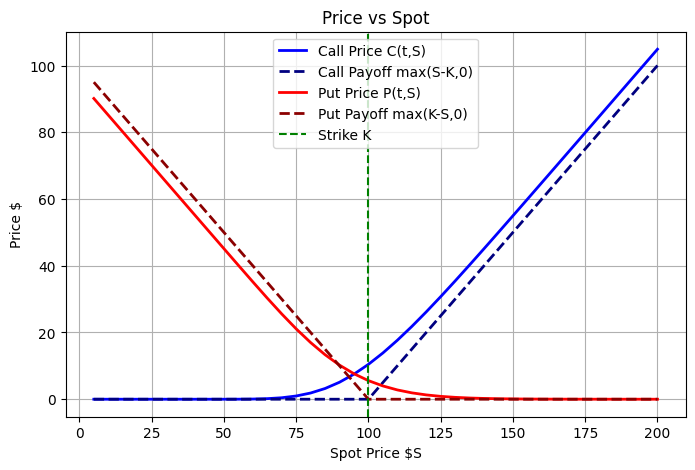

In [6]:
call = CallOption(strike, maturity)
put = PutOption(strike, maturity)

plt.figure(figsize=(8,5))
plt.plot(x_axis, call.price(x_axis, 0, rate, sigma), color='blue', label='Call Price C(t,S)', linewidth=2)
plt.plot(x_axis, call.payoff(x_axis), '--', color='navy', label='Call Payoff max(S-K,0)', linewidth=2)
plt.plot(x_axis, put.price(x_axis, 0, rate, sigma), color='red', label='Put Price P(t,S)', linewidth=2)
plt.plot(x_axis, put.payoff(x_axis), '--', color='darkred', label='Put Payoff max(K-S,0)', linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label='Strike K')
plt.xlabel('Spot Price $S')
plt.ylabel('Price $')
plt.title('Price vs Spot')
plt.legend()
plt.grid(True)

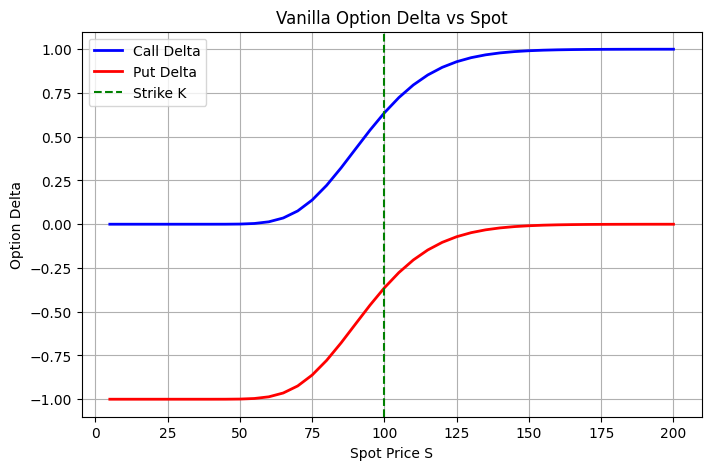

In [7]:
plt.figure(figsize=(8,5))
plt.plot(x_axis, call.delta(x_axis, 0, rate, sigma), color='blue', label='Call Delta', linewidth=2)
plt.plot(x_axis, put.delta(x_axis, 0, rate, sigma), color='red', label='Put Delta', linewidth=2)
plt.axvline(strike, color='green', linestyle='--', label='Strike K')
plt.xlabel('Spot Price S')
plt.ylabel('Option Delta')
plt.title('Vanilla Option Delta vs Spot')
plt.legend()
plt.grid(True)

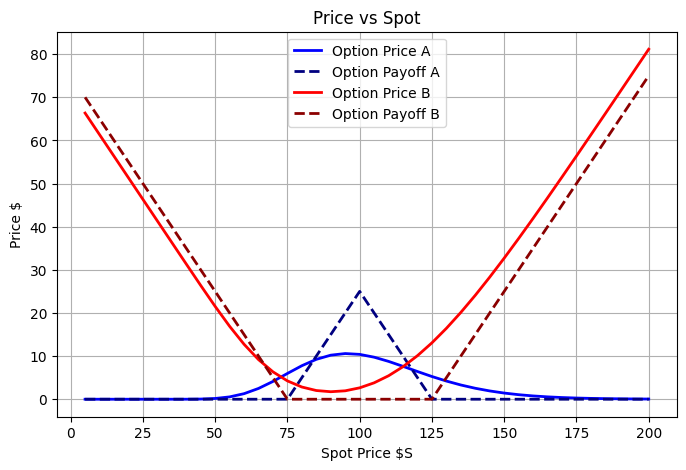

In [8]:
bull_call = CallOption(90,1) - CallOption(110,1)
butterfly = CallOption(75, 1) - 2*CallOption(100, 1) + CallOption(125, 1)
condor = PutOption(50,1) - PutOption(60,1) - CallOption(140,1) + CallOption(150,1)
straddle = CallOption(100,1) + PutOption(100,1)
strangle = CallOption(125,1) + PutOption(75,1)

combo_option_1 = butterfly
combo_option_2 = strangle

plt.figure(figsize=(8,5))
plt.plot(x_axis, combo_option_1.price(x_axis, 0, rate, sigma), color='blue', label='Option Price A', linewidth=2)
plt.plot(x_axis, combo_option_1.payoff(x_axis), '--', color='navy', label='Option Payoff A', linewidth=2)
plt.plot(x_axis, combo_option_2.price(x_axis, 0, rate, sigma), color='red', label='Option Price B', linewidth=2)
plt.plot(x_axis, combo_option_2.payoff(x_axis), '--', color='darkred', label='Option Payoff B', linewidth=2)
plt.xlabel('Spot Price $S')
plt.ylabel('Price $')
plt.title('Price vs Spot')
plt.legend()
plt.grid(True)

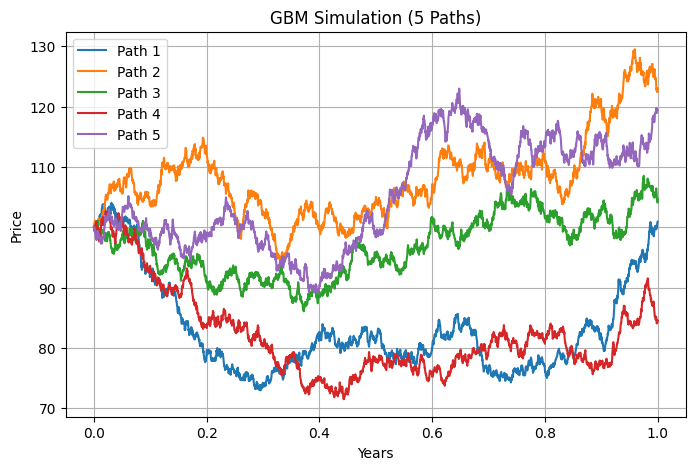

In [10]:
spot = 100
drift = 0.08
maturity = 1
sigma = 0.2
mesh = 1/252
runs = 5

underlying = GeometricBrownianMotion(spot, drift, sigma, maturity, runs, mesh, 10)

time_grid = np.linspace(0, maturity, underlying.length+1)
plt.figure(figsize=(8,5))
for i in range(runs):
    plt.plot(time_grid, underlying.paths[i], label=f'Path {i+1}')

plt.title(f'GBM Simulation ({runs} Paths)')
plt.xlabel('Years')
plt.ylabel('Price')
plt.legend()
plt.grid(True)